# Threshold Counts + Trajectories – N=2, |++⟩

For each η₂ ∈ {1.0, 0.8, 0.6, 0.4} (with η₁=1 fixed), compute per trajectory:
ξ²_KU, ξ²_WIN, F_Q (SLD), χ²=N/F_Q.

**Threshold plots:** how many trajectories, time by time, satisfy ξ²<1 / F_Q>2 / χ²>1.

**Trajectories plot:** individual trajectories + ensemble average for each η₂.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from qutip import (
    basis, ket2dm, qeye, sigmax, sigmay, sigmaz,
    smesolve, tensor
)
print('Imports OK')

Imports OK


In [2]:
# ── Stile LaTeX ────────────────────────────────────────────────────────────
plt.rcParams["text.usetex"] = True
plt.rcParams.update({
    "mathtext.fontset" : "cm",
    "font.family"      : "serif",
    "font.size"        : 14,
    "axes.unicode_minus": False,
})

In [ ]:
# ── Parameters ─────────────────────────────────────────────────────────────
# === Run configuration (modify here for each run) ===
theta_css   = np.pi / 2
phi_css     = 0.0
state_label = "PlusPlus"
# =====================================================

N_SPIN     = 2
gamma      = 1.0
phi1       = 0.0
phi2       = 0.0
T_END      = 5.0
dt         = 0.005          # time step in units of T1 — must be <= 0.005
ntraj      = 200

assert dt <= 0.005, f"dt={dt} exceeds maximum allowed value of 0.005"
N_TIMES = int(round(T_END / dt)) + 1

eta_1      = 1.0
eta_values = [1.0, 0.8, 0.5, 0.0]

THRESH_XI   = 0.98
THRESH_CHI2 = 0.98

times = np.linspace(0.0, T_END, N_TIMES)
t1    = 1.0 / gamma
x     = times / t1

out_dir = Path(f"Graphs/QFI/ntraj{ntraj}_{state_label}")
out_dir.mkdir(parents=True, exist_ok=True)

print(f'dt = {dt},  N_TIMES = {N_TIMES},  T_END = {T_END},  T1 = {t1}')
print(f'ntraj = {ntraj},  eta_1 = {eta_1},  eta_2 values = {eta_values}')
print(f'Thresholds: THRESH_XI={THRESH_XI},  THRESH_CHI2={THRESH_CHI2}')
print(f'Initial state: CSS(theta={theta_css/np.pi:.4f}*pi),  label = {state_label}')
print(f'Output dir: {out_dir}')

In [4]:
# ── Operatori ──────────────────────────────────────────────────────────────
I2  = qeye(2)
Jx  = 0.5 * (tensor(sigmax(), I2) + tensor(I2, sigmax()))
Jy  = 0.5 * (tensor(sigmay(), I2) + tensor(I2, sigmay()))
Jz  = 0.5 * (tensor(sigmaz(), I2) + tensor(I2, sigmaz()))

Cp = np.sqrt(0.5) * (tensor(sigmaz(), I2) + tensor(I2, sigmaz()))
Cm = np.sqrt(0.5) * (tensor(sigmaz(), I2) - tensor(I2, sigmaz()))
H_free = 0.0 * Jz

plus_x = (basis(2, 0) + basis(2, 1)).unit()
rho0   = ket2dm(tensor(plus_x, plus_x))

# Precompute in numpy
SPIN_NP = [Jx.full(), Jy.full(), Jz.full()]
AC_NP   = np.zeros((3, 3, 4, 4), dtype=complex)
for i, Ji in enumerate([Jx, Jy, Jz]):
    for j, Jj in enumerate([Jx, Jy, Jz]):
        AC_NP[i, j] = (Ji * Jj + Jj * Ji).full()

print('Operatori pronti.')

Operatori pronti.


In [5]:
# ── Funzioni osservabili (numpy, valide per stati misti) ───────────────────
def compute_all_obs(rho_np):
    tol = 1e-12
    means = np.array([np.real(np.trace(Ji @ rho_np)) for Ji in SPIN_NP])
    m     = np.linalg.norm(means)

    C = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            C[i, j] = np.real(0.5 * np.trace(AC_NP[i, j] @ rho_np)
                              - means[i] * means[j])

    if m > tol:
        u  = means / m
        a  = np.array([1., 0., 0.]) if abs(u[0]) < 0.9 else np.array([0., 1., 0.])
        e1 = a - u * np.dot(u, a);  e1 /= np.linalg.norm(e1)
        e2 = np.cross(u, e1)
        C2 = np.array([[e1@C@e1, e1@C@e2], [e2@C@e1, e2@C@e2]])
        lam = max(np.linalg.eigvalsh(C2)[0], 0.0)
    else:
        lam = max(np.linalg.eigvalsh(C)[0], 0.0)

    xi_ku  = float(4.0 / N_SPIN * lam)
    xi_win = xi_ku * ((N_SPIN / 2.0) / m) ** 2 if m > tol else xi_ku

    # QFI ottimale via SLD (esatta per stati misti)
    evals, evecs = np.linalg.eigh(rho_np)
    evals = np.maximum(evals, 0.0)
    J_eig = [evecs.conj().T @ Ji @ evecs for Ji in SPIN_NP]
    Mf = np.zeros((3, 3))
    for k in range(4):
        for l in range(4):
            denom = evals[k] + evals[l]
            if denom < tol:
                continue
            pf  = 2.0 * (evals[k] - evals[l]) ** 2 / denom
            Jkl = np.array([J_eig[i][k, l] for i in range(3)])
            Mf += pf * np.real(np.outer(Jkl, Jkl.conj()))
    qfi = max(float(np.linalg.eigvalsh(Mf).max()), 0.0)
    chi2 = float(N_SPIN / qfi) if qfi > tol else np.inf

    return xi_ku, xi_win, qfi, chi2

print('Funzioni definite.')

Funzioni definite.


In [6]:
# ── Simulation ─────────────────────────────────────────────────────────────
XI_KU  = np.zeros((len(eta_values), ntraj, N_TIMES))
XI_WIN = np.zeros((len(eta_values), ntraj, N_TIMES))
QFI    = np.zeros((len(eta_values), ntraj, N_TIMES))
CHI2   = np.zeros((len(eta_values), ntraj, N_TIMES))

def c_ops_fn(eta_2):
    # Unobserved noise: skip if eta=1 (no dissipation)
    ops = []
    if eta_1 < 1.0:
        ops.append(np.sqrt(gamma * (1.0 - eta_1)) * Cp)
    if eta_2 < 1.0:
        ops.append(np.sqrt(gamma * (1.0 - eta_2)) * Cm)
    return ops

def sc_ops_fn(eta_2):
    # Observed channels: skip zero operators (eta=0)
    ops = [np.sqrt(gamma * eta_1) * Cp]
    if eta_2 > 0.0:
        ops.append(np.sqrt(gamma * eta_2) * Cm)
    return ops

for i_eta, eta_2 in enumerate(eta_values):
    print(f'\n─── eta_1 = {eta_1},  eta_2 = {eta_2} ───')
    sol = smesolve(
        H_free, rho0, times,
        c_ops=c_ops_fn(eta_2), sc_ops=sc_ops_fn(eta_2),
        heterodyne=False, ntraj=ntraj,
        options={'keep_runs_results': True, 'map': 'serial',
                 'store_measurement': False},
    )
    print('  SME done. Computing observables...')
    for i_traj in range(ntraj):
        if i_traj % 50 == 0:
            print(f'    traj {i_traj}/{ntraj}')
        for i_t, state in enumerate(sol.runs_states[i_traj]):
            rho_np = np.array(state.full(), dtype=complex)
            xk, xw, qf, c2 = compute_all_obs(rho_np)
            XI_KU [i_eta, i_traj, i_t] = xk
            XI_WIN[i_eta, i_traj, i_t] = xw
            QFI   [i_eta, i_traj, i_t] = qf
            CHI2  [i_eta, i_traj, i_t] = c2
    del sol
    print(f'  eta_2 = {eta_2} done.')

print('\nSimulation complete!')


─── eta_1 = 1.0,  eta_2 = 1.0 ───


10.0%. Run time:   5.69s. Est. time left: 00:00:00:51


20.0%. Run time:  11.14s. Est. time left: 00:00:00:44


30.0%. Run time:  16.55s. Est. time left: 00:00:00:38


40.0%. Run time:  22.17s. Est. time left: 00:00:00:33


...

Total run time:  47.00s
  SME done. Computing observables...
    traj 0/200


    traj 50/200


    traj 100/200


    traj 150/200


  eta_2 = 0.0 done.

Simulation complete!


In [7]:
# ── Threshold counts (with tolerance) ─────────────────────────────────────
# F_Q > N/THRESH_CHI2  ↔  χ² = N/F_Q < THRESH_CHI2
THRESH_QFI = N_SPIN / THRESH_CHI2   # e.g. 2/0.98 ≈ 2.04

cnt_xi_ku  = (XI_KU  < THRESH_XI  ).sum(axis=1)
cnt_xi_win = (XI_WIN < THRESH_XI  ).sum(axis=1)
cnt_qfi    = (QFI    > THRESH_QFI ).sum(axis=1)
cnt_chi2   = (CHI2   < THRESH_CHI2).sum(axis=1)

frac_xi_ku  = cnt_xi_ku  / ntraj
frac_xi_win = cnt_xi_win / ntraj
frac_qfi    = cnt_qfi    / ntraj
frac_chi2   = cnt_chi2   / ntraj

print(f'Classification thresholds: xi<{THRESH_XI}, chi2<{THRESH_CHI2}, F_Q>{THRESH_QFI:.4f}')
print('Fraction arrays shape:', frac_xi_ku.shape)

Classification thresholds: xi<0.98, chi2<0.98, F_Q>2.0408
Fraction arrays shape: (4, 501)


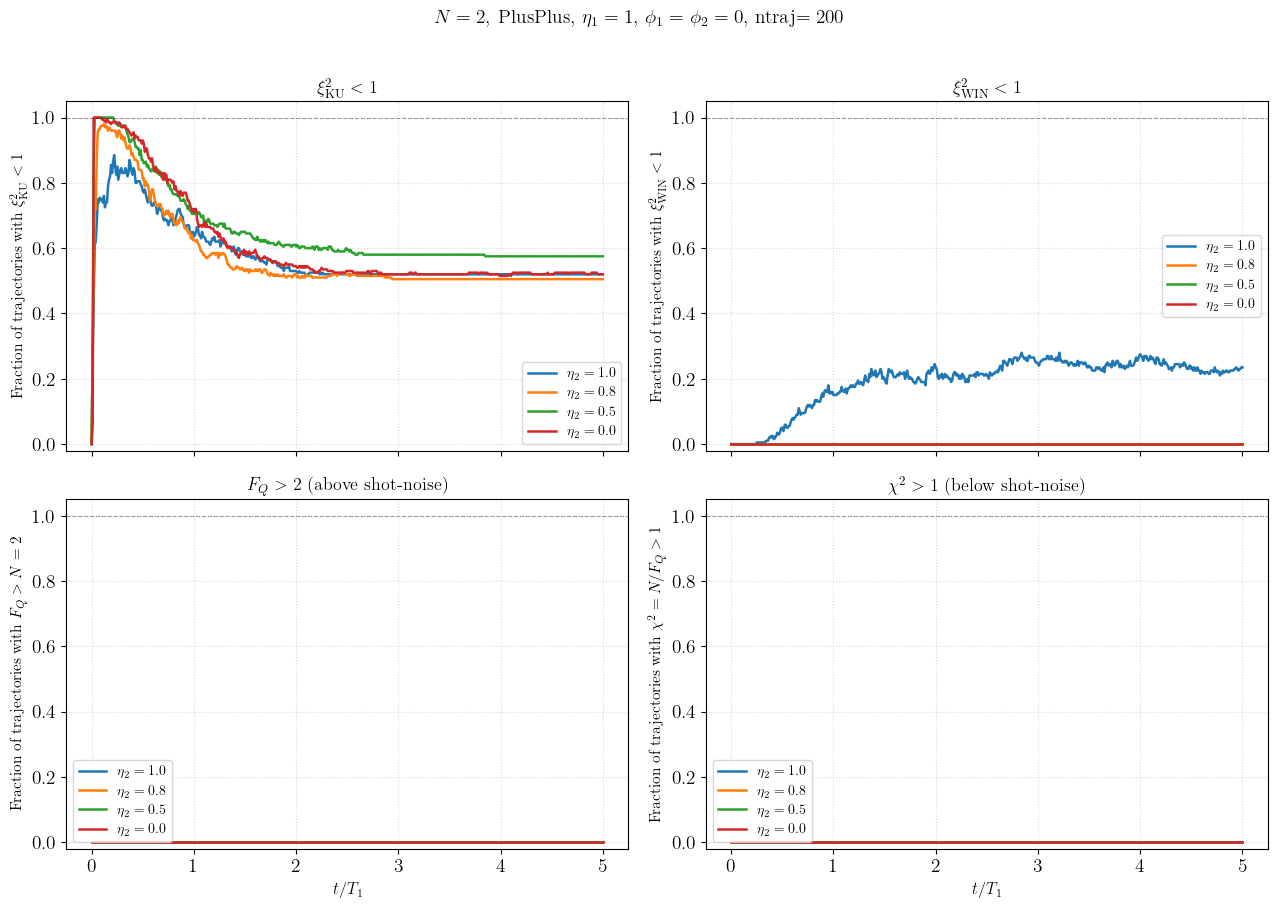

Saved: Graphs\QFI\ntraj200_PlusPlus\threshold_counts_PlusPlus_ntraj200.pdf


In [8]:
# ── Fig 1: one condition per panel, 5 eta_2 curves ────────────────────────
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
lw = 1.8

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

panels = [
    (axes[0, 0], frac_xi_ku,
     r'$\xi^2_{\mathrm{KU}} < 1$',
     r'Fraction of trajectories with $\xi^2_{\mathrm{KU}} < 1$'),
    (axes[0, 1], frac_xi_win,
     r'$\xi^2_{\mathrm{WIN}} < 1$',
     r'Fraction of trajectories with $\xi^2_{\mathrm{WIN}} < 1$'),
    (axes[1, 0], frac_qfi,
     r'$F_Q > 2$ (above shot-noise)',
     r'Fraction of trajectories with $F_Q > N = 2$'),
    (axes[1, 1], frac_chi2,
     r'$\chi^2 > 1$ (below shot-noise)',
     r'Fraction of trajectories with $\chi^2 = N/F_Q > 1$'),
]

for ax, frac, title, ylabel in panels:
    for i_eta, (eta_2, col) in enumerate(zip(eta_values, colors)):
        ax.plot(x, frac[i_eta], color=col, lw=lw,
                label=rf'$\eta_2 = {eta_2}$')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(-0.02, 1.05)
    ax.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.35)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, linestyle=':', alpha=0.5)

for ax in axes[1]:
    ax.set_xlabel(r'$t/T_1$', fontsize=12)

fig.suptitle(
    rf'$N=2$, {state_label}, $\eta_1=1$, $\phi_1=\phi_2=0$, ntraj$={ntraj}$',
    fontsize=14, y=1.01
)
plt.tight_layout()
fname = out_dir / f'threshold_counts_{state_label}_ntraj{ntraj}.pdf'
plt.savefig(fname, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fname}')

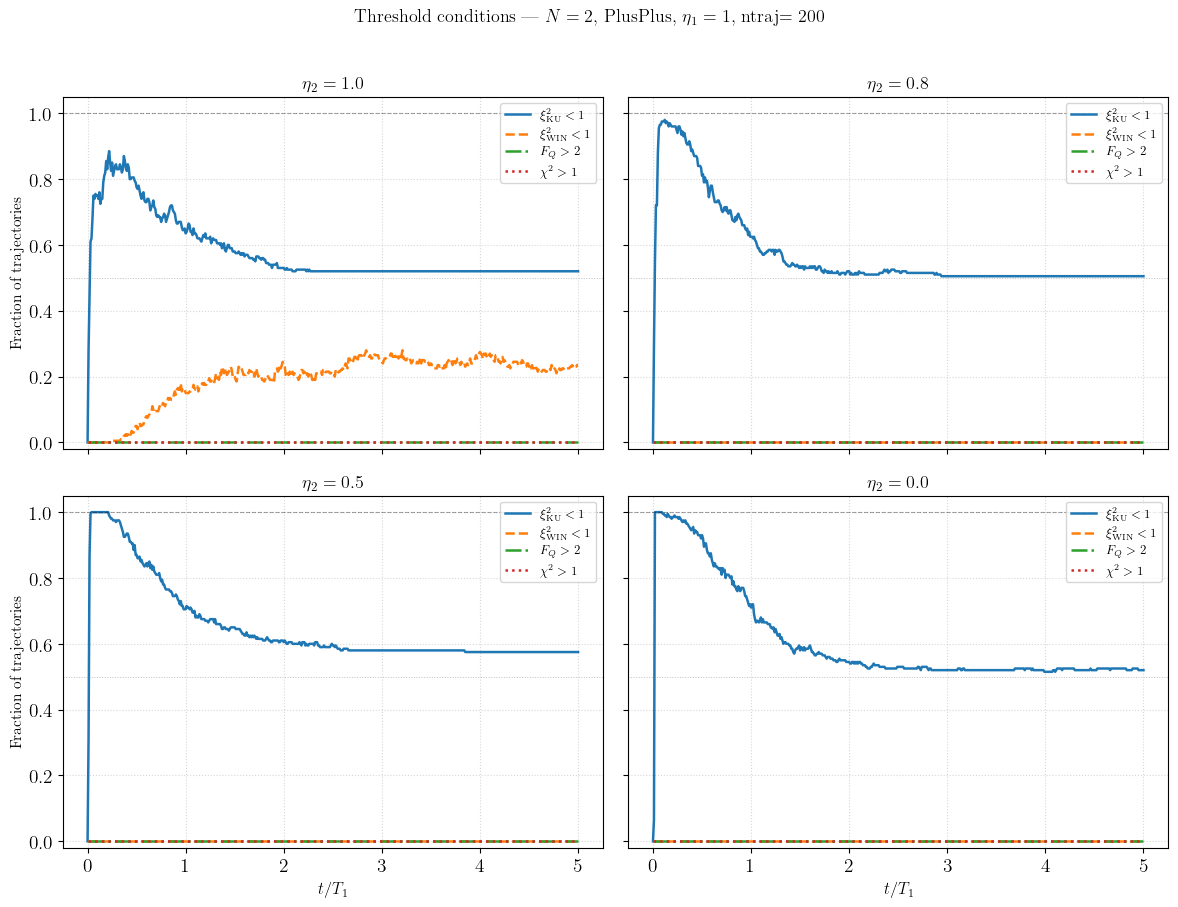

Saved: Graphs\QFI\ntraj200_PlusPlus\threshold_counts_PlusPlus_ntraj200_by_eta.pdf


In [9]:
# ── Fig 2: one panel per eta_2, grid adapts to n_eta ───────────────────────
import math
n_eta  = len(eta_values)
n_cols = 3 if n_eta > 4 else 2
n_rows = math.ceil(n_eta / n_cols)

cond_specs = [
    (frac_xi_ku,  r'$\xi^2_{\mathrm{KU}}<1$',  'tab:blue',   '-'),
    (frac_xi_win, r'$\xi^2_{\mathrm{WIN}}<1$', 'tab:orange',  '--'),
    (frac_qfi,    r'$F_Q>2$',                  'tab:green',   '-.'),
    (frac_chi2,   r'$\chi^2>1$',               'tab:red',     ':'),
]

fig2, axes2 = plt.subplots(n_rows, n_cols,
                            figsize=(6*n_cols, 4.5*n_rows),
                            sharex=True, sharey=True)
axes2_flat = axes2.flatten() if n_eta > 1 else [axes2]

for i_eta, (eta_2, ax) in enumerate(zip(eta_values, axes2_flat)):
    for frac, label, col, ls in cond_specs:
        ax.plot(x, frac[i_eta], color=col, ls=ls, lw=lw, label=label)
    ax.set_title(rf'$\eta_2 = {eta_2}$', fontsize=13)
    ax.set_ylim(-0.02, 1.05)
    ax.axhline(0.5, color='gray', ls=':', lw=0.7, alpha=0.5)
    ax.axhline(1.0, color='k',    ls='--', lw=0.8, alpha=0.35)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, linestyle=':', alpha=0.5)
    if i_eta % n_cols == 0:
        ax.set_ylabel(r'Fraction of trajectories', fontsize=11)
    if i_eta >= (n_rows - 1) * n_cols:
        ax.set_xlabel(r'$t/T_1$', fontsize=12)

# Hide unused panels
for ax in axes2_flat[n_eta:]:
    ax.set_visible(False)

fig2.suptitle(
    rf'Threshold conditions — $N=2$, {state_label}, $\eta_1=1$, ntraj$={ntraj}$',
    fontsize=13, y=1.01
)
plt.tight_layout()
fname2 = out_dir / f'threshold_counts_{state_label}_ntraj{ntraj}_by_eta.pdf'
plt.savefig(fname2, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fname2}')

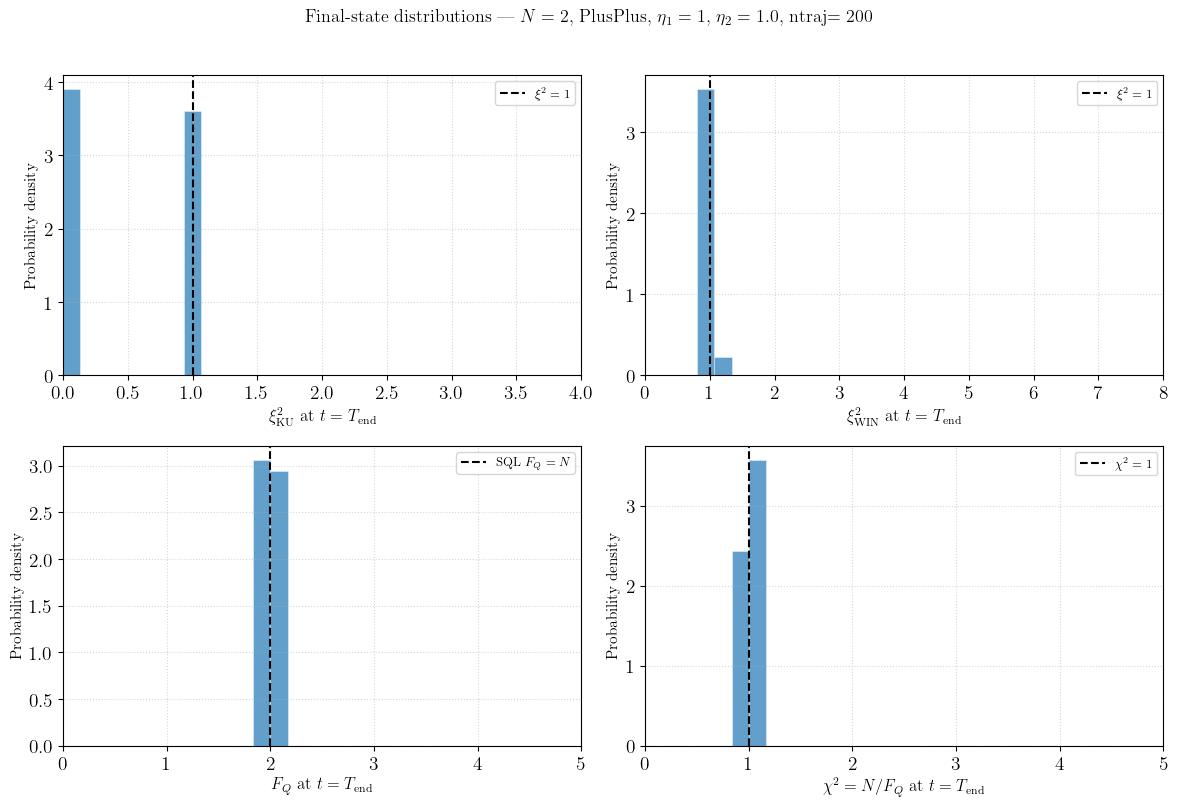

Saved: Graphs\QFI\ntraj200_PlusPlus\histograms_final_PlusPlus_ntraj200_eta2_1.0.pdf


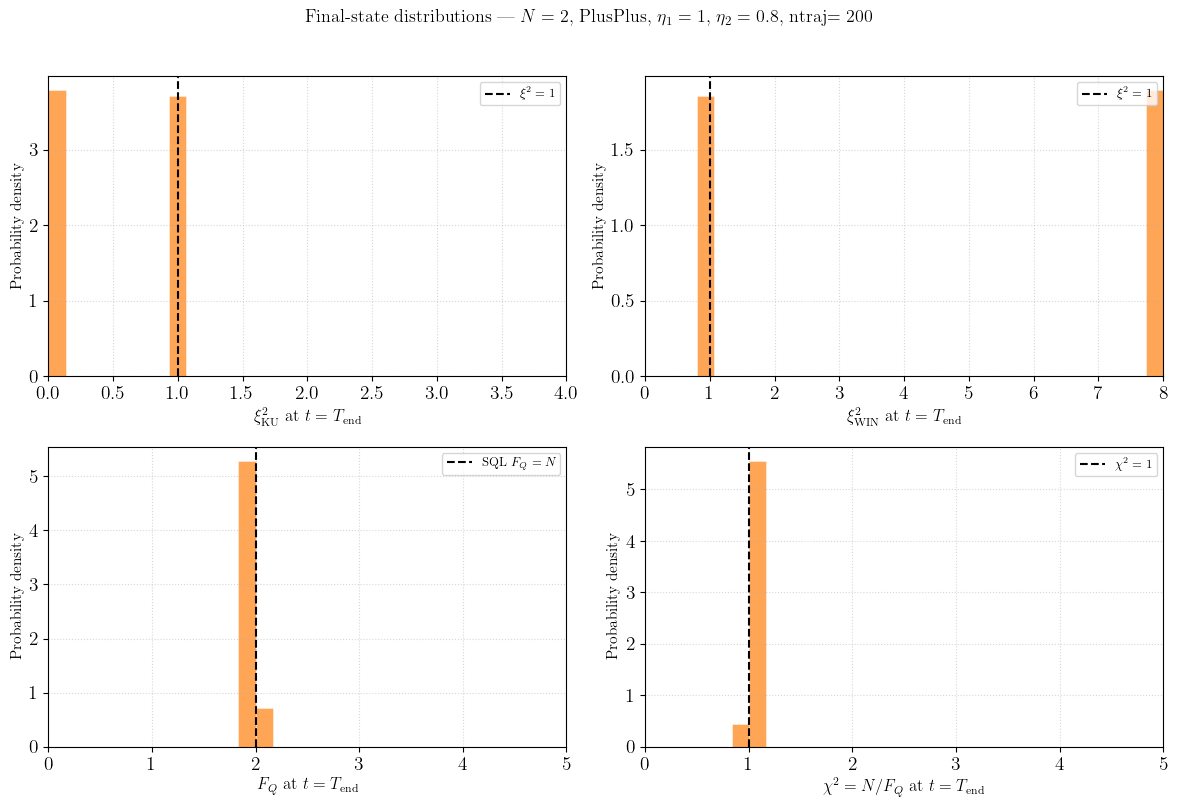

Saved: Graphs\QFI\ntraj200_PlusPlus\histograms_final_PlusPlus_ntraj200_eta2_0.8.pdf


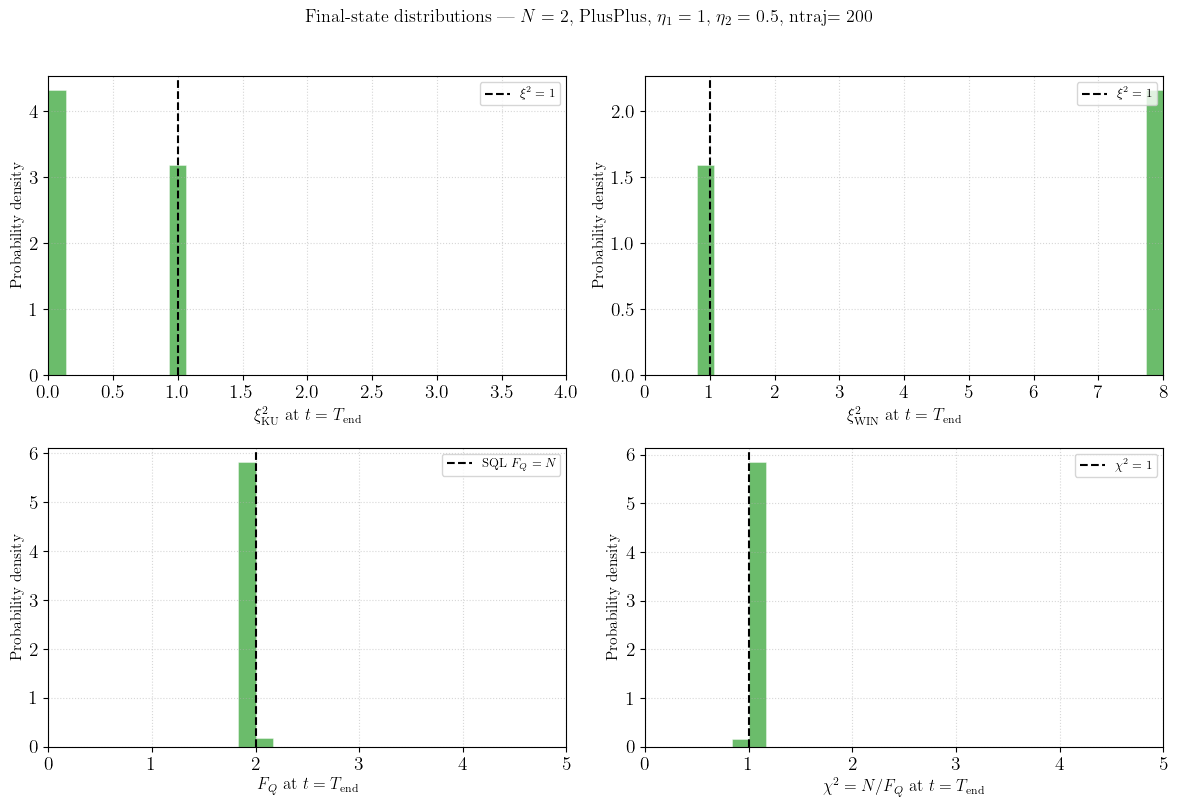

Saved: Graphs\QFI\ntraj200_PlusPlus\histograms_final_PlusPlus_ntraj200_eta2_0.5.pdf


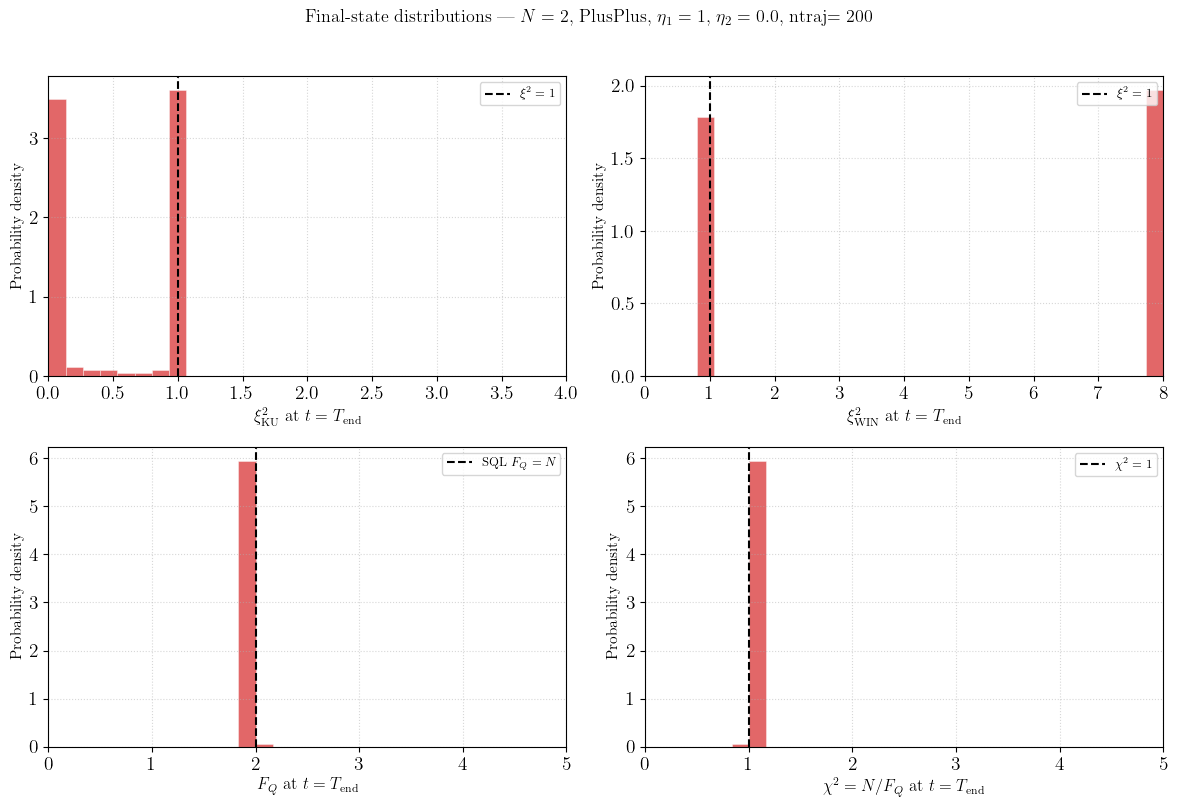

Saved: Graphs\QFI\ntraj200_PlusPlus\histograms_final_PlusPlus_ntraj200_eta2_0.0.pdf


In [10]:
# ── Fig 3: histograms of final-state observables — one figure per eta_2 ────
xi_ku_final  = XI_KU [:, :, -1]   # (n_eta, ntraj)
xi_win_final = XI_WIN[:, :, -1]
qfi_final    = QFI   [:, :, -1]
chi2_final   = CHI2  [:, :, -1]

hist_specs = [
    (xi_ku_final,  r'$\xi^2_{\mathrm{KU}}$',  1.0, r'$\xi^2=1$',   (0.0, 4.0), 30),
    (xi_win_final, r'$\xi^2_{\mathrm{WIN}}$', 1.0, r'$\xi^2=1$',   (0.0, 8.0), 30),
    (qfi_final,    r'$F_Q$',                  2.0, r'SQL $F_Q=N$', (0.0, 5.0), 30),
    (chi2_final,   r'$\chi^2 = N/F_Q$',       1.0, r'$\chi^2=1$',  (0.0, 5.0), 30),
]

for i_eta, (eta_2, col) in enumerate(zip(eta_values, colors)):
    fig_h, axes_h = plt.subplots(2, 2, figsize=(12, 8))

    for ax, (data, xlabel, vline_val, vline_lbl, (xlo, xhi), bins) in \
            zip(axes_h.flat, hist_specs):
        d = np.clip(data[i_eta], xlo, xhi)
        ax.hist(d, bins=bins, range=(xlo, xhi),
                color=col, alpha=0.7, density=True, edgecolor='white', linewidth=0.4)
        ax.axvline(vline_val, color='k', ls='--', lw=1.5, label=vline_lbl)
        ax.set_xlabel(xlabel + r'  at $t=T_{\mathrm{end}}$', fontsize=12)
        ax.set_ylabel(r'Probability density', fontsize=11)
        ax.set_xlim(xlo, xhi)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.5)

    fig_h.suptitle(
        rf'Final-state distributions — $N=2$, {state_label},'
        rf' $\eta_1=1$, $\eta_2={eta_2}$, ntraj$={ntraj}$',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    fname_h = out_dir / f'histograms_final_{state_label}_ntraj{ntraj}_eta2_{eta_2}.pdf'
    plt.savefig(str(fname_h), bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {fname_h}')

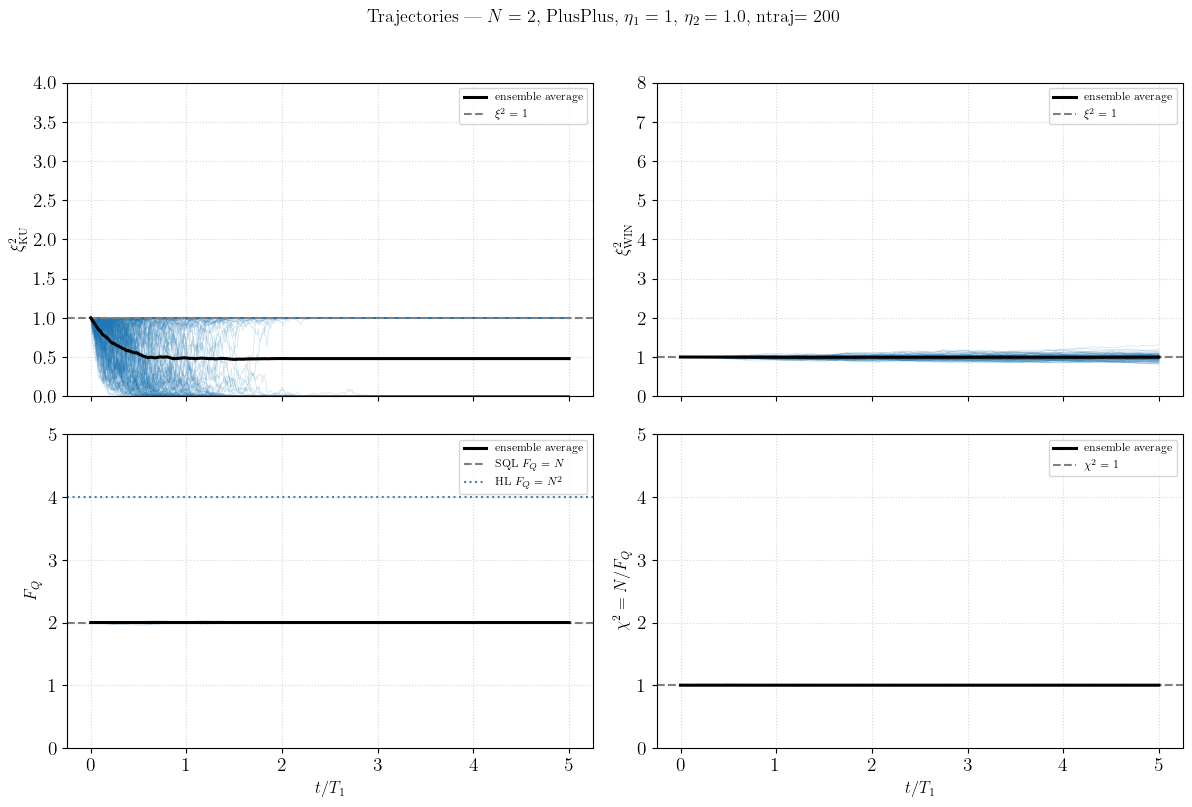

Saved: Graphs\QFI\ntraj200_PlusPlus\trajectories_PlusPlus_ntraj200_eta2_1.0.pdf


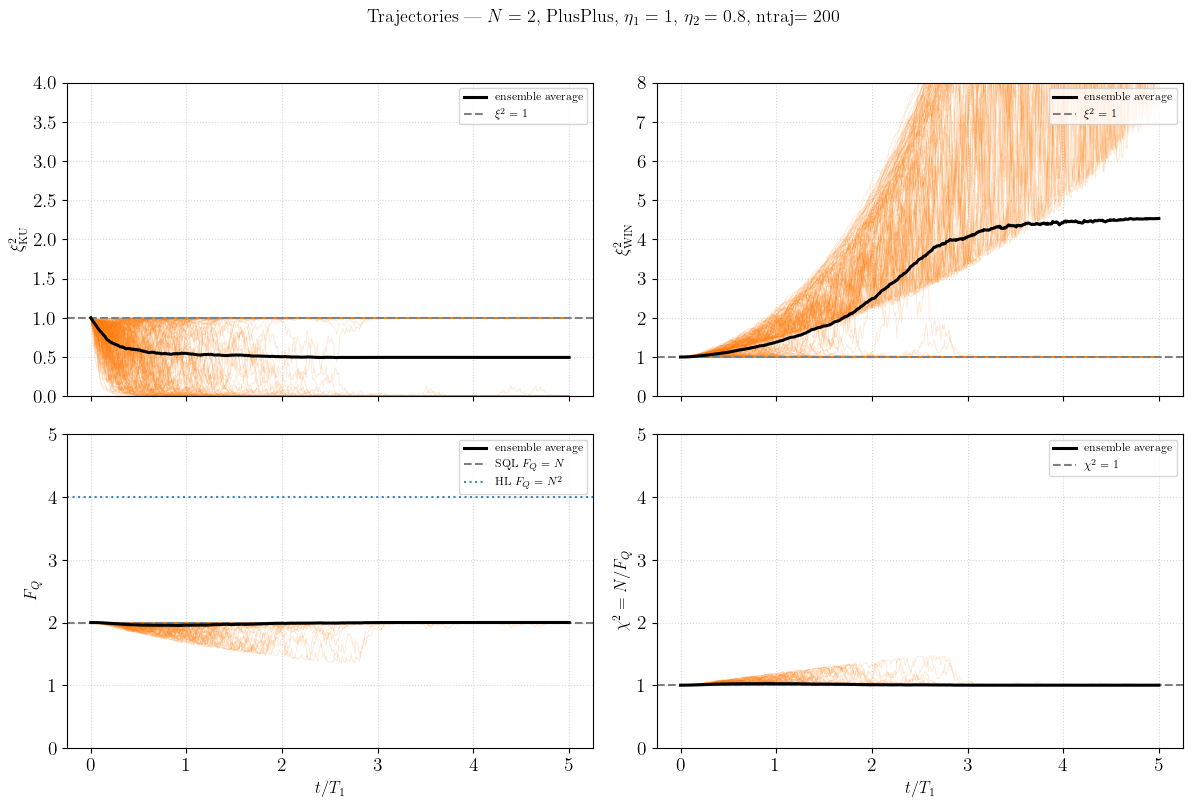

Saved: Graphs\QFI\ntraj200_PlusPlus\trajectories_PlusPlus_ntraj200_eta2_0.8.pdf


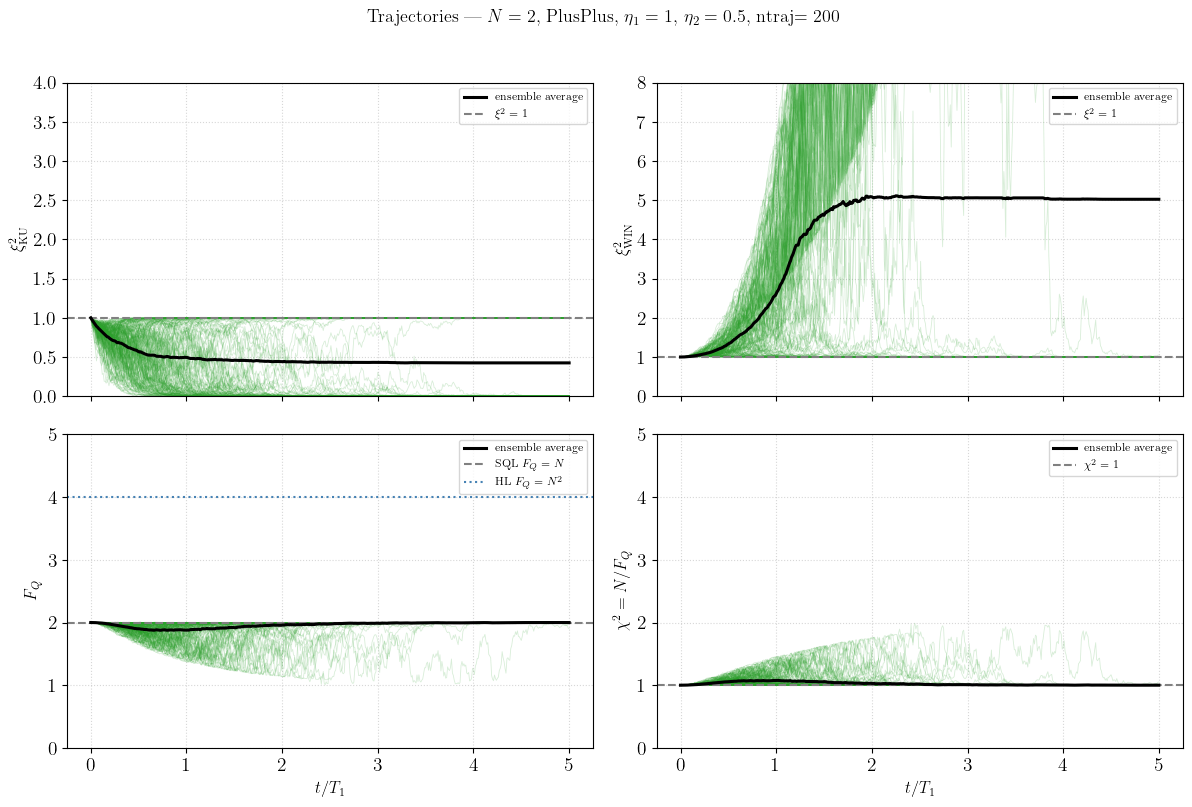

Saved: Graphs\QFI\ntraj200_PlusPlus\trajectories_PlusPlus_ntraj200_eta2_0.5.pdf


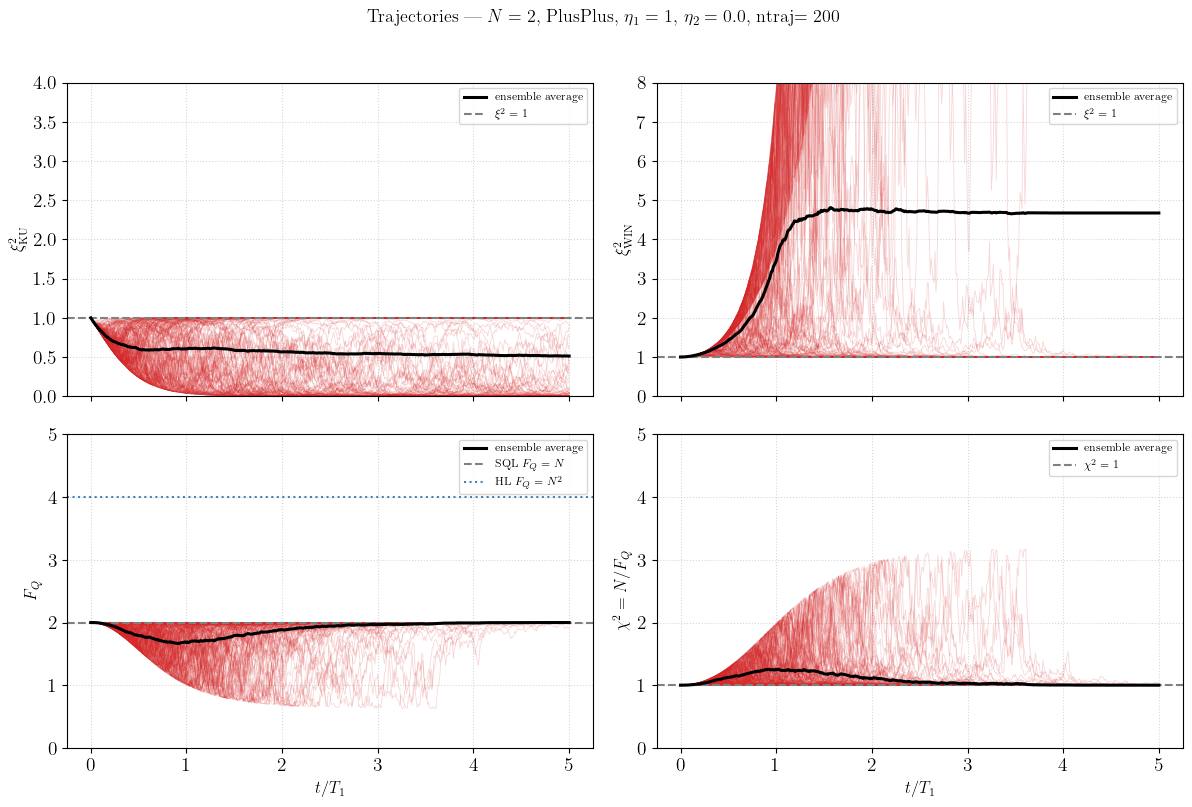

Saved: Graphs\QFI\ntraj200_PlusPlus\trajectories_PlusPlus_ntraj200_eta2_0.0.pdf


In [11]:
# ── Trajectories plot: 2×2 panel per eta_2 ─────────────────────────────────
CLIP = {
    'xi_ku' : (0.0, 4.0),
    'xi_win': (0.0, 8.0),
    'qfi'   : (0.0, 5.0),
    'chi2'  : (0.0, 5.0),
}

obs_specs = [
    (XI_KU,  r'$\xi^2_{\mathrm{KU}}$',  'xi_ku',
     [(1.0, 'gray',      '--', r'$\xi^2=1$')]),
    (XI_WIN, r'$\xi^2_{\mathrm{WIN}}$', 'xi_win',
     [(1.0, 'gray',      '--', r'$\xi^2=1$')]),
    (QFI,    r'$F_Q$',                  'qfi',
     [(2.0, 'gray',      '--', r'SQL $F_Q=N$'),
      (4.0, 'steelblue', ':',  r'HL $F_Q=N^2$')]),
    (CHI2,   r'$\chi^2 = N/F_Q$',       'chi2',
     [(1.0, 'gray',      '--', r'$\chi^2=1$')]),
]

traj_palette = colors  # 5 colours for 5 eta_2 values

for i_eta, (eta_2, traj_col) in enumerate(zip(eta_values, traj_palette)):
    fig_s, axes_s = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

    for ax, (data, ylabel, key, hlines_info) in zip(axes_s.flat, obs_specs):
        ylo, yhi = CLIP[key]
        d = np.clip(data[i_eta], ylo, yhi)  # (ntraj, N_TIMES)

        for i_traj in range(ntraj):
            ax.plot(x, d[i_traj], color=traj_col, alpha=0.18, lw=0.6)

        ax.plot(x, d.mean(axis=0),
                color='black', lw=2.2, zorder=5, label=r'ensemble average')

        for yval, col, ls, lbl in hlines_info:
            ax.axhline(yval, color=col, ls=ls, lw=1.5, label=lbl)

        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(ylo, yhi)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.5)

    for ax in axes_s[1]:
        ax.set_xlabel(r'$t/T_1$', fontsize=12)

    fig_s.suptitle(
        rf'Trajectories — $N=2$, {state_label},'
        rf' $\eta_1=1$, $\eta_2={eta_2}$, ntraj$={ntraj}$',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    fname_s = out_dir / f'trajectories_{state_label}_ntraj{ntraj}_eta2_{eta_2}.pdf'
    plt.savefig(str(fname_s), bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {fname_s}')

In [12]:
# ── Equivalence analysis: ξ²_WIN < THRESH_XI  vs  χ² < THRESH_CHI2 ─────────
WIN_bool = XI_WIN < THRESH_XI
CHI_bool = CHI2   < THRESH_CHI2

frac_both      = ( WIN_bool &  CHI_bool).mean(axis=1)
frac_only_win  = ( WIN_bool & ~CHI_bool).mean(axis=1)
frac_only_chi  = (~WIN_bool &  CHI_bool).mean(axis=1)
frac_neither   = (~WIN_bool & ~CHI_bool).mean(axis=1)
frac_agree     = frac_both + frac_neither
frac_disagree  = frac_only_win + frac_only_chi

print(f'Contingency with THRESH_XI={THRESH_XI}, THRESH_CHI2={THRESH_CHI2}')
print(f'Max total disagreement: {frac_disagree.max():.4f}')

Contingency with THRESH_XI=0.98, THRESH_CHI2=0.98
Max total disagreement: 0.2800


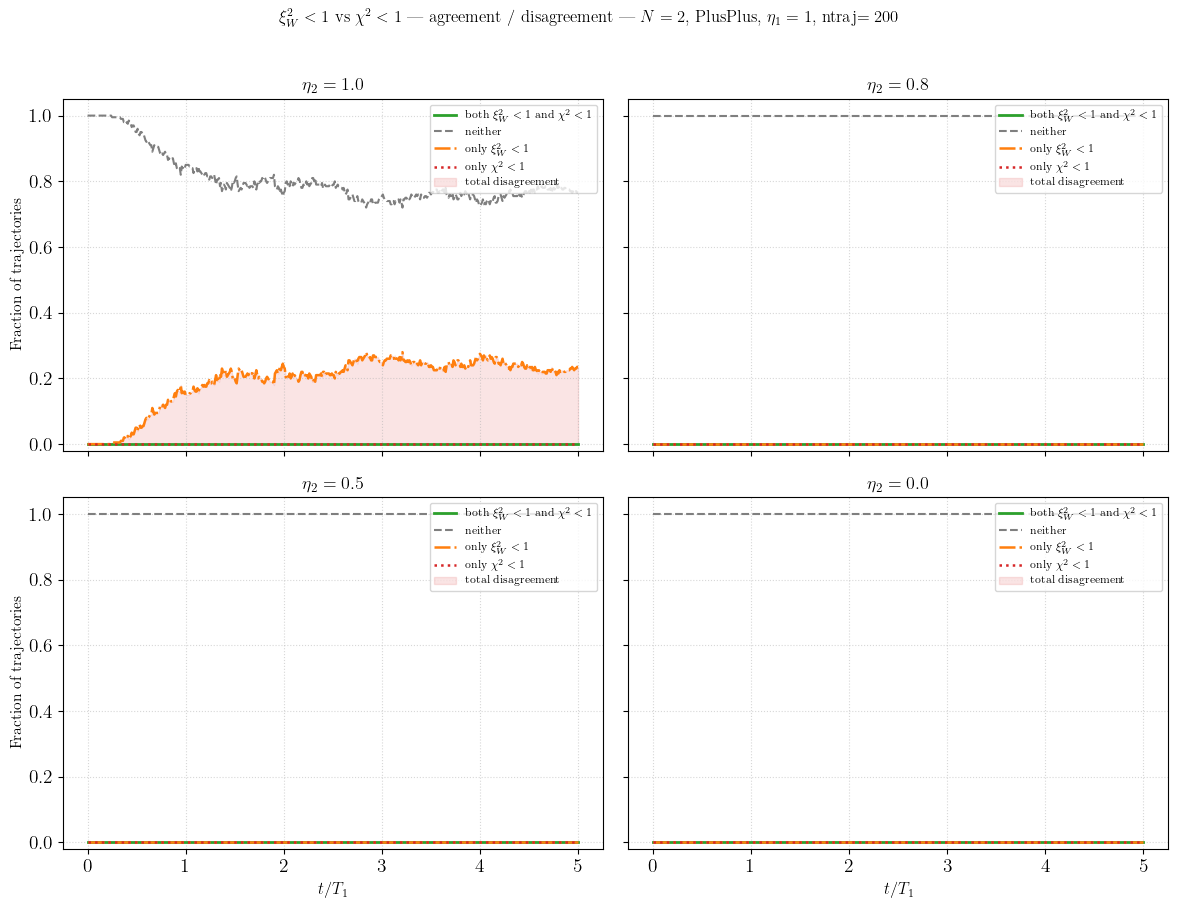

Saved: Graphs\QFI\ntraj200_PlusPlus\contingency_PlusPlus_ntraj200.pdf


In [13]:
# ── Fig: contingency fractions vs time — one panel per eta_2 ───────────────
cat_specs = [
    (frac_both,     r'both $\xi^2_W<1$ and $\chi^2<1$', 'tab:green',  '-',   2.0),
    (frac_neither,  r'neither',                          'tab:gray',   '--',  1.5),
    (frac_only_win, r'only $\xi^2_W<1$',                'tab:orange', '-.',  1.8),
    (frac_only_chi, r'only $\chi^2<1$',                 'tab:red',    ':',   1.8),
]

n_eta  = len(eta_values)
n_cols = 3 if n_eta > 4 else 2
n_rows = math.ceil(n_eta / n_cols)

fig_c, axes_c = plt.subplots(n_rows, n_cols,
                              figsize=(6*n_cols, 4.5*n_rows),
                              sharex=True, sharey=True)
axes_c_flat = axes_c.flatten() if n_eta > 1 else [axes_c]

for i_eta, (eta_2, ax) in enumerate(zip(eta_values, axes_c_flat)):
    for frac, lbl, col, ls, lw_i in cat_specs:
        ax.plot(x, frac[i_eta], color=col, ls=ls, lw=lw_i, label=lbl)
    # highlight total disagreement as shaded area
    ax.fill_between(x, frac_disagree[i_eta], alpha=0.12, color='tab:red',
                    label=r'total disagreement')
    ax.set_title(rf'$\eta_2={eta_2}$', fontsize=13)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.5)
    if i_eta % n_cols == 0:
        ax.set_ylabel(r'Fraction of trajectories', fontsize=11)
    if i_eta >= (n_rows-1)*n_cols:
        ax.set_xlabel(r'$t/T_1$', fontsize=12)

for ax in axes_c_flat[n_eta:]:
    ax.set_visible(False)

fig_c.suptitle(
    rf'$\xi^2_W<1$ vs $\chi^2<1$ — agreement / disagreement'
    rf' — $N=2$, {state_label}, $\eta_1=1$, ntraj$={ntraj}$',
    fontsize=12, y=1.01
)
plt.tight_layout()
fname_c = out_dir / f'contingency_{state_label}_ntraj{ntraj}.pdf'
plt.savefig(fname_c, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fname_c}')

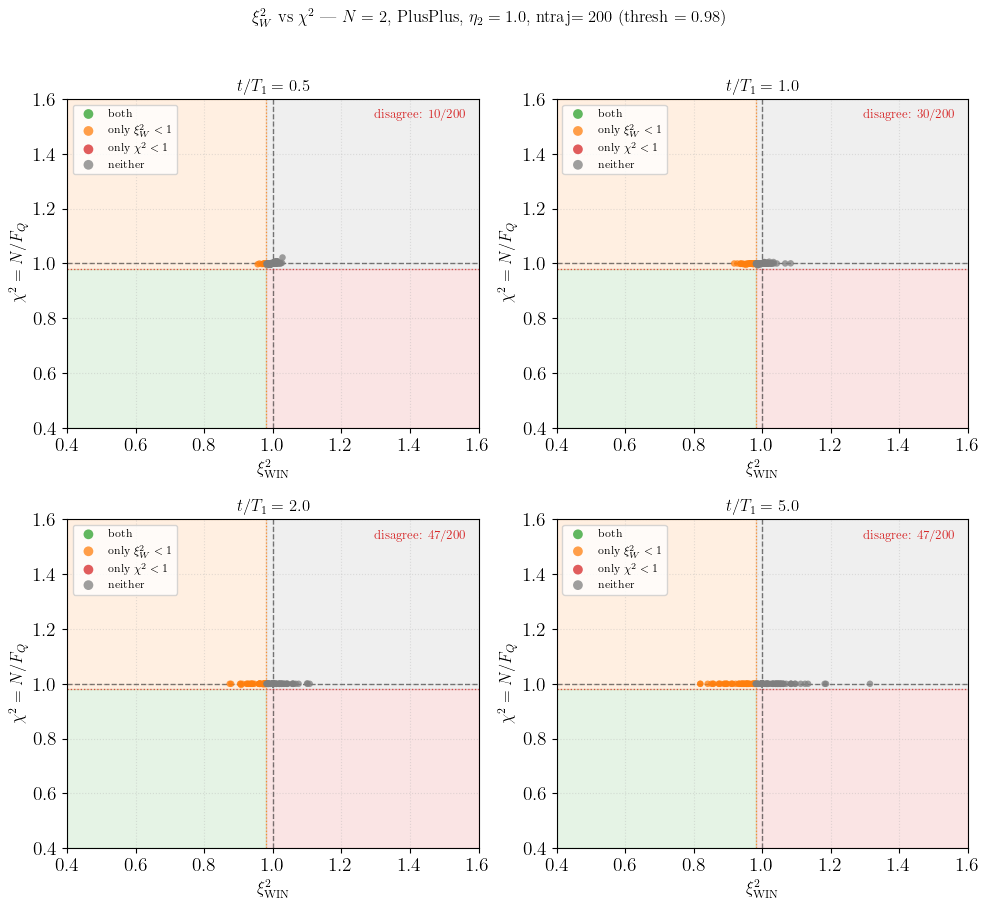

Saved: Graphs\QFI\ntraj200_PlusPlus\scatter_win_chi2_PlusPlus_ntraj200_eta2_1.0.pdf


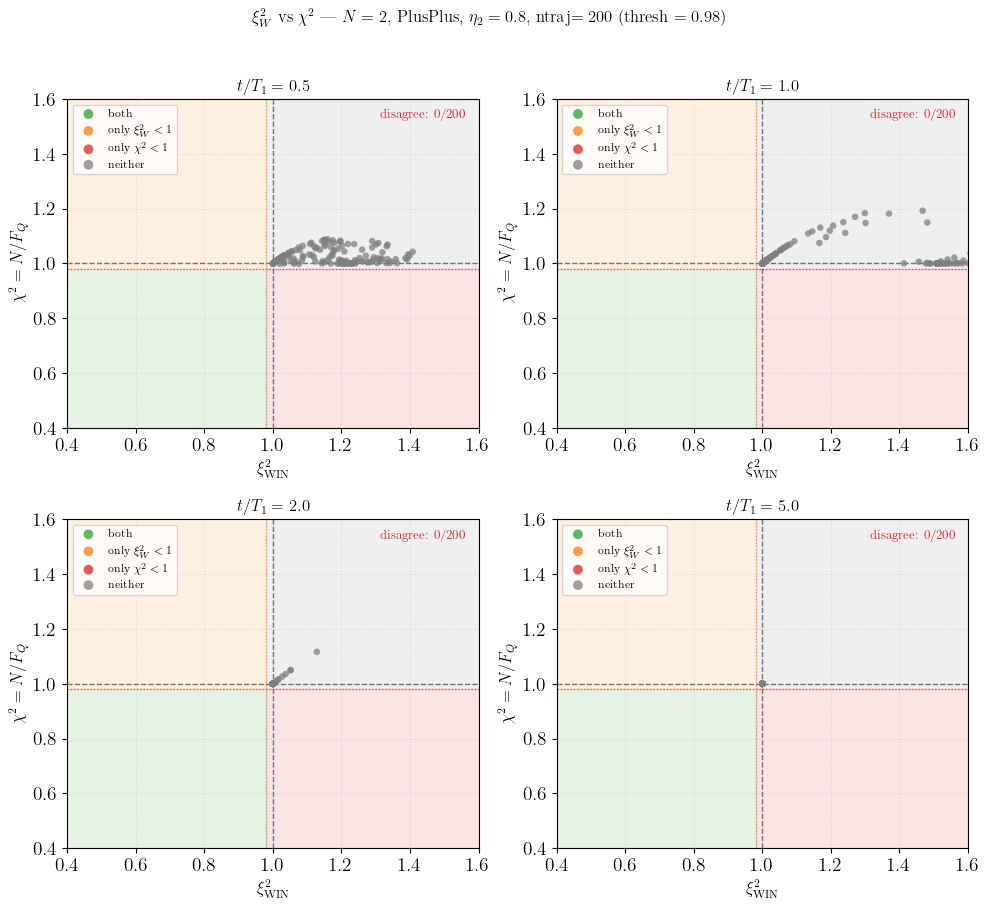

Saved: Graphs\QFI\ntraj200_PlusPlus\scatter_win_chi2_PlusPlus_ntraj200_eta2_0.8.pdf


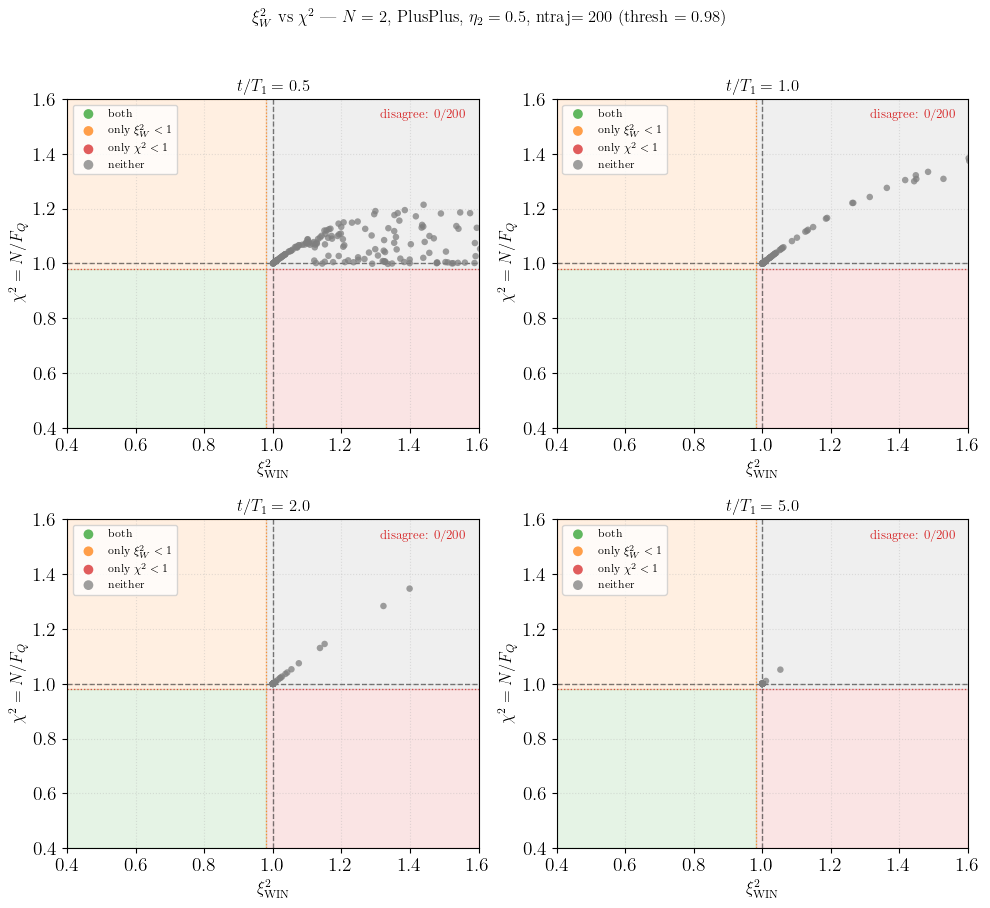

Saved: Graphs\QFI\ntraj200_PlusPlus\scatter_win_chi2_PlusPlus_ntraj200_eta2_0.5.pdf


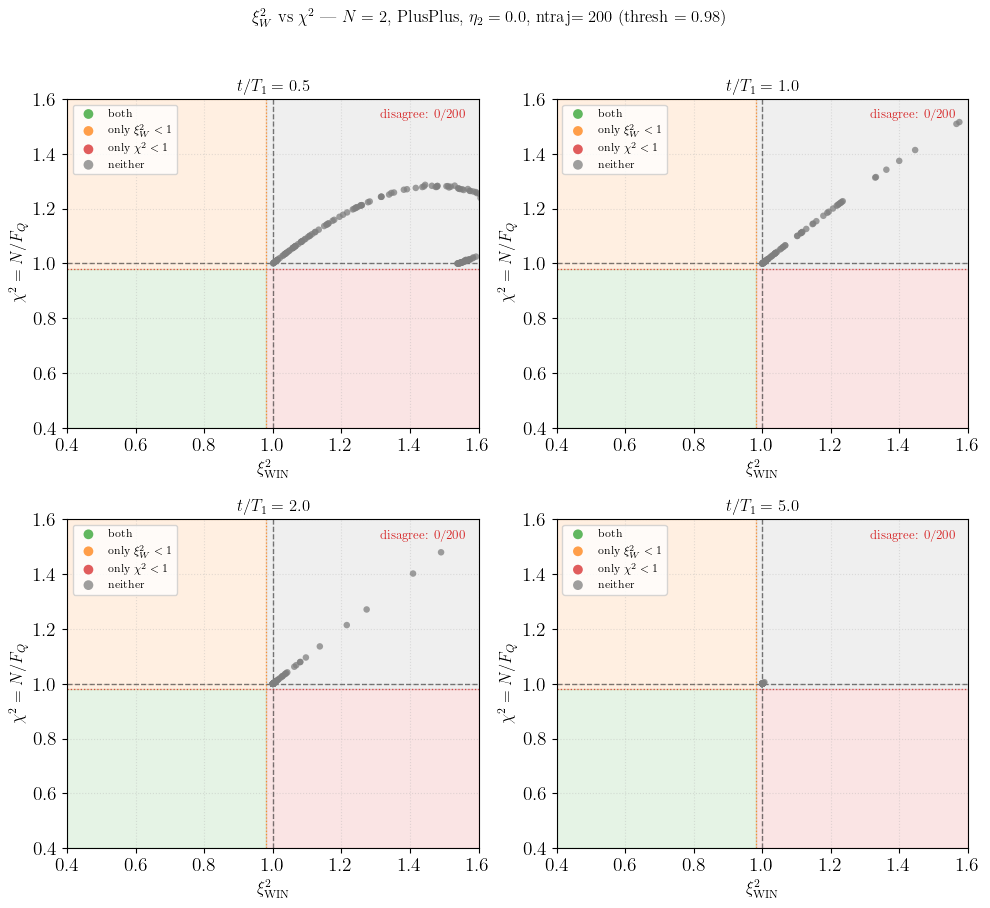

Saved: Graphs\QFI\ntraj200_PlusPlus\scatter_win_chi2_PlusPlus_ntraj200_eta2_0.0.pdf


In [14]:
# ── Scatter ξ²_WIN vs χ² at temporal snapshots — zoomed on (1,1) ───────────
from matplotlib.patches import Rectangle

snap_tT1 = [0.5, 1.0, 2.0, 5.0]
snap_idx  = [int(np.argmin(np.abs(x - s))) for s in snap_tT1]

ZOOM = 0.6
xlo, xhi = max(0, 1 - ZOOM), 1 + ZOOM
ylo, yhi = max(0, 1 - ZOOM), 1 + ZOOM

Q_ALPHA = 0.12   # background quadrant transparency

for i_eta, (eta_2, col) in enumerate(zip(eta_values, colors)):
    fig_sc, axes_sc = plt.subplots(2, 2, figsize=(10, 9))

    for ax, (idx, tval) in zip(axes_sc.flat, zip(snap_idx, snap_tT1)):
        xw = XI_WIN[i_eta, :, idx]
        xc = CHI2  [i_eta, :, idx]

        mask_both     =  (xw < THRESH_XI)  &  (xc < THRESH_CHI2)
        mask_only_win =  (xw < THRESH_XI)  & ~(xc < THRESH_CHI2)
        mask_only_chi = ~(xw < THRESH_XI)  &  (xc < THRESH_CHI2)
        mask_neither  = ~(xw < THRESH_XI)  & ~(xc < THRESH_CHI2)

        # ── coloured quadrant backgrounds ──────────────────────────────────
        tx, ty = THRESH_XI, THRESH_CHI2
        quads = [
            (xlo, ylo, tx-xlo, ty-ylo,  'tab:green'),   # bottom-left  → both
            (xlo, ty,  tx-xlo, yhi-ty,  'tab:orange'),  # top-left     → only WIN
            (tx,  ylo, xhi-tx, ty-ylo,  'tab:red'),     # bottom-right → only χ²
            (tx,  ty,  xhi-tx, yhi-ty,  'tab:gray'),    # top-right    → neither
        ]
        for (rx, ry, rw, rh, rcol) in quads:
            ax.add_patch(Rectangle((rx, ry), rw, rh,
                                   color=rcol, alpha=Q_ALPHA, zorder=0))

        # ── scatter points ──────────────────────────────────────────────────
        kw = dict(alpha=0.75, s=22, edgecolors='none', zorder=3)
        ax.scatter(xw[mask_both],     xc[mask_both],     color='tab:green',  label='both',               **kw)
        ax.scatter(xw[mask_only_win], xc[mask_only_win], color='tab:orange', label=r'only $\xi^2_W<1$',  **kw)
        ax.scatter(xw[mask_only_chi], xc[mask_only_chi], color='tab:red',    label=r'only $\chi^2<1$',   **kw)
        ax.scatter(xw[mask_neither],  xc[mask_neither],  color='tab:gray',   label='neither',            **kw)

        # hard threshold lines at 1
        ax.axhline(1.0, color='k',          lw=1.0, ls='--', alpha=0.5, zorder=2)
        ax.axvline(1.0, color='k',          lw=1.0, ls='--', alpha=0.5, zorder=2)
        # effective classification threshold lines
        ax.axhline(ty,  color='tab:red',    lw=0.9, ls=':',  alpha=0.8, zorder=2)
        ax.axvline(tx,  color='tab:orange', lw=0.9, ls=':',  alpha=0.8, zorder=2)

        n_dis = (mask_only_win | mask_only_chi).sum()
        ax.text(0.97, 0.97,
                rf'disagree: {n_dis}/{ntraj}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                color='tab:red')

        ax.set_xlim(xlo, xhi)
        ax.set_ylim(ylo, yhi)
        ax.set_xlabel(r'$\xi^2_{\mathrm{WIN}}$', fontsize=12)
        ax.set_ylabel(r'$\chi^2 = N/F_Q$',        fontsize=12)
        ax.set_title(rf'$t/T_1 = {tval}$', fontsize=12)
        ax.legend(fontsize=8, loc='upper left', markerscale=1.5)
        ax.grid(True, linestyle=':', alpha=0.35, zorder=1)

    fig_sc.suptitle(
        rf'$\xi^2_W$ vs $\chi^2$ — $N=2$, {state_label},'
        rf' $\eta_2={eta_2}$, ntraj$={ntraj}$'
        rf' (thresh $={THRESH_CHI2}$)',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    fname_sc = out_dir / f'scatter_win_chi2_{state_label}_ntraj{ntraj}_eta2_{eta_2}.pdf'
    plt.savefig(fname_sc, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {fname_sc}')